# 06: Media Coverage Trends & Peak Detection

Produces:
- A bar chart of the top media outlets covering the league.
- A monthly coverage trend chart (with a linear trendline).
- A statistical peak-detection report (`scipy.find_peaks`) for both peak **months** and peak **days**, with sample headlines, exported to CSV.
- YouTube channel growth for the NWSL's official channel and the wider ecosystem of women's-soccer/sports-specific media channels.
- Positive vs. negative media coverage share over time (VADER sentiment, from `05`).

Uses the shared color theme in `plot_theme.py` so every chart in this repo reads as part of the same project.

**Inputs:** `data/processed/nwsl_articles_filtered.csv`, `nwsl_articles_with_sentiment.csv`, `youtube_channels.csv`, `youtube_videos.csv`
**Outputs:** `output/nwsl_articles_by_media_outlet.png`, `output/nwsl_articles_trend_over_time.png`, `output/youtube_subscriber_snapshot.png`, `output/youtube_nwsl_channel_growth.png`, `output/youtube_womens_media_rise.png`, `output/nwsl_sentiment_share_by_year.png`, `data/processed/monthly_peaks.csv`, `data/processed/daily_peaks.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import find_peaks
import os

from plot_theme import set_mpl_theme

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

set_mpl_theme()

media = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_articles_filtered.csv"))
media["publish_date"] = pd.to_datetime(media["publish_date"])
print(f"Loaded {len(media)} filtered articles")


Loaded 8328 filtered articles


## Top media outlets covering the NWSL

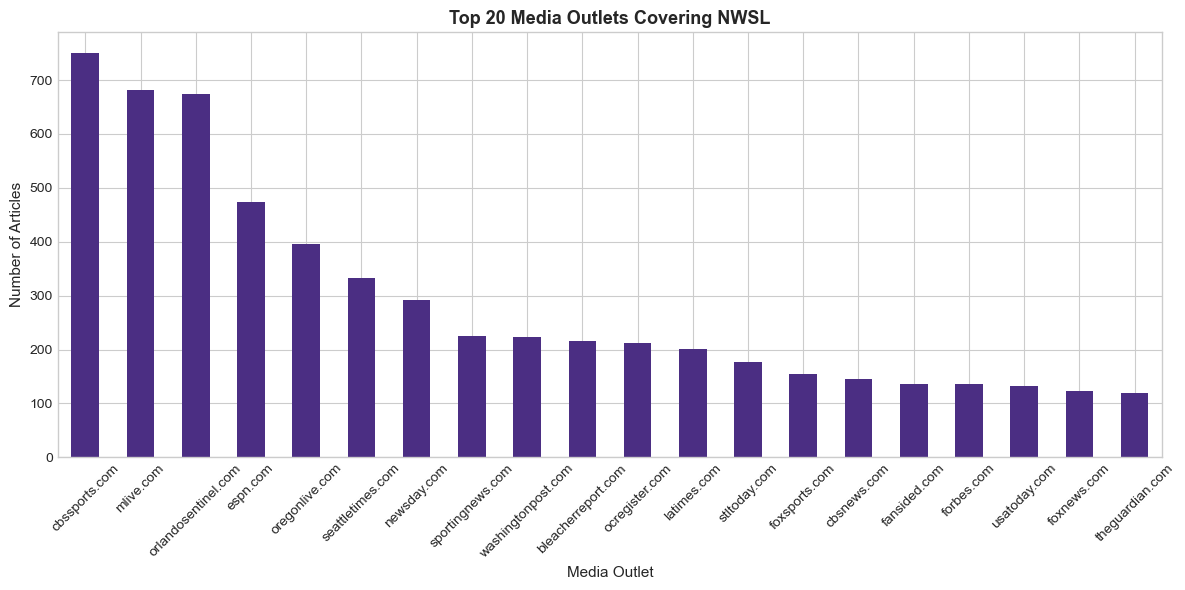

In [2]:
def plot_top_outlets(media, top_n=20, out_path=None):
    """Bar chart of the top N media outlets by article count."""
    plt.figure(figsize=(12, 6))
    media["media_name"].value_counts().head(top_n).plot(kind="bar")
    plt.title(f"Top {top_n} Media Outlets Covering NWSL")
    plt.xlabel("Media Outlet")
    plt.ylabel("Number of Articles")
    plt.xticks(rotation=45)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path)
    plt.show()
    plt.close()


plot_top_outlets(media, out_path=os.path.join(OUTPUT_DIR, "nwsl_articles_by_media_outlet.png"))


## Monthly coverage trend

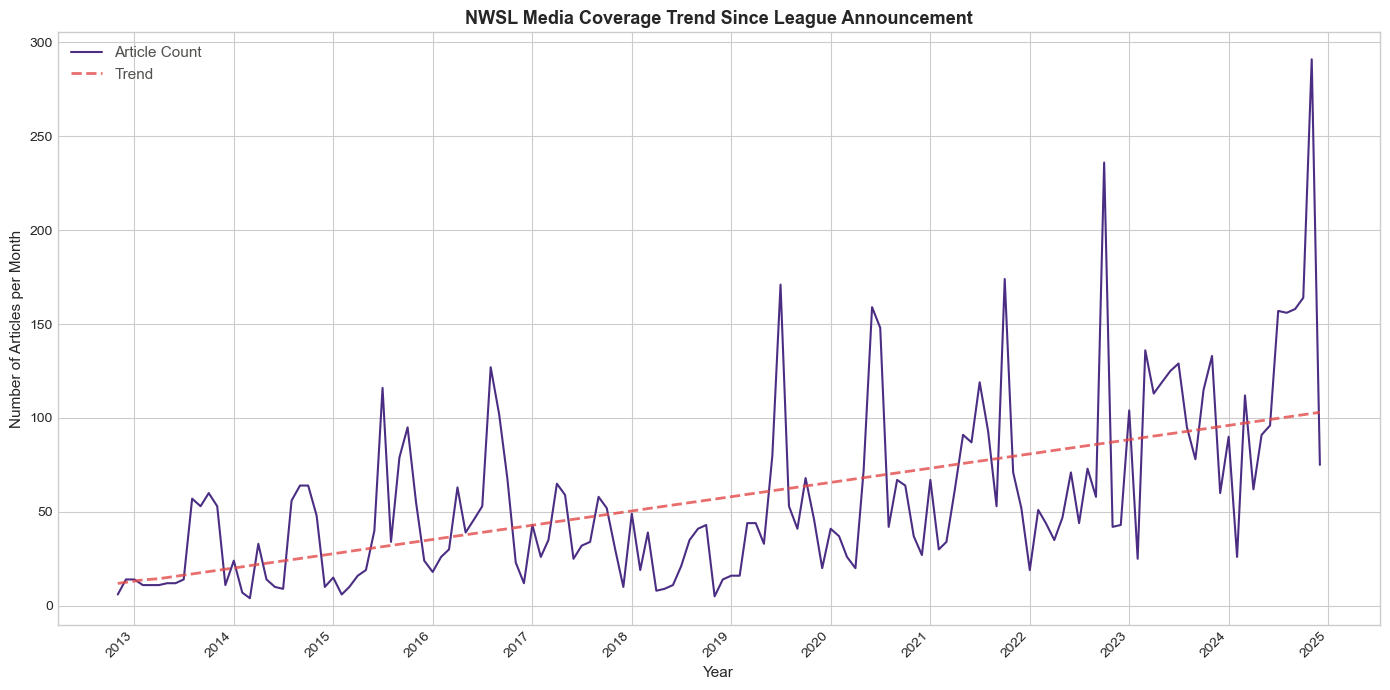

In [3]:
def monthly_counts(media):
    """Return a Series of article counts indexed by month (Timestamp)."""
    counts = media["publish_date"].dt.to_period("M").value_counts().sort_index()
    counts.index = counts.index.to_timestamp()
    return counts


def plot_monthly_trend(monthly, out_path=None):
    """Line chart of monthly article counts with a linear trendline."""
    x = monthly.index
    y = monthly.values
    x_numeric = np.arange(len(x))

    slope, intercept = np.polyfit(x_numeric, y, 1)
    y_trend = slope * x_numeric + intercept

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x, y, label="Article Count")
    ax.plot(x, y_trend, linewidth=2, color="#e34948", linestyle="--", alpha=0.8, label="Trend")

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 7)))

    ax.set_title("NWSL Media Coverage Trend Since League Announcement")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Articles per Month")
    plt.xticks(rotation=45, ha="right")
    ax.legend(loc="upper left", frameon=False, fontsize=11, labelcolor="#52514e")
    ax.set_facecolor("white")

    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
    plt.show()
    plt.close(fig)


monthly = monthly_counts(media)
plot_monthly_trend(monthly, out_path=os.path.join(OUTPUT_DIR, "nwsl_articles_trend_over_time.png"))


## Peak detection (months and days)

In [4]:
def find_significant_peaks(x, y, prominence_factor, distance):
    """Run scipy.find_peaks and return results as a sorted DataFrame."""
    peaks, properties = find_peaks(y, prominence=np.std(y) * prominence_factor, distance=distance)
    peak_df = pd.DataFrame({
        "date": x[peaks],
        "article_count": y[peaks],
        "prominence": properties["prominences"],
    }).sort_values("article_count", ascending=False)
    return peak_df


In [5]:
def report_monthly_peaks(media, monthly, top_n=10, out_path=None):
    """Print a report of statistically significant peak months with sample headlines,
    and export the peaks (with a day_of_week-equivalent month label) to CSV."""
    x = monthly.index
    y = monthly.values

    peak_df = find_significant_peaks(x, y, prominence_factor=0.5, distance=3)
    threshold = np.mean(y) + 1.5 * np.std(y)

    print("=== SIGNIFICANT PEAKS IN ARTICLE FREQUENCY ===\n")
    print(f"Average monthly articles: {np.mean(y):.0f}")
    print(f"Standard deviation: {np.std(y):.0f}")
    print(f"Threshold for significance: {threshold:.0f}\n")
    print(peak_df.to_string(index=False))
    print(f"\nTotal significant peaks found: {len(peak_df)}")

    print("\n=== PEAK DETAILS ===")
    for _, row in peak_df.head(top_n).iterrows():
        month_str = row["date"].strftime("%B %Y")
        print(f"\n{month_str}: {row['article_count']} articles")

        month_period = row["date"].to_period("M")
        month_mask = media["publish_date"].dt.to_period("M") == month_period
        sample_titles = media.loc[month_mask, "title"].head(3)
        for title in sample_titles:
            print(f"  \u2022 {title[:80]}...")

    if out_path:
        peak_df.to_csv(out_path, index=False)
        print(f"\nExported {len(peak_df)} peak months to '{out_path}'")

    return peak_df


monthly_peaks = report_monthly_peaks(
    media, monthly, out_path=os.path.join(DATA_PROCESSED_DIR, "monthly_peaks.csv")
)


=== SIGNIFICANT PEAKS IN ARTICLE FREQUENCY ===

Average monthly articles: 57
Standard deviation: 48
Threshold for significance: 129

      date  article_count  prominence
2024-11-01            291       216.0
2022-10-01            236       211.0
2021-10-01            174       155.0
2019-07-01            171       151.0
2020-06-01            159       132.0
2023-03-01            136       110.0
2023-11-01            133        55.0
2016-08-01            127       122.0
2021-07-01            119        66.0
2015-07-01            116        98.0
2024-03-01            112        50.0
2015-10-01             95        61.0
2022-06-01             71        27.0
2019-10-01             68        27.0
2020-09-01             67        25.0
2021-01-01             67        37.0
2017-04-01             65        53.0
2014-09-01             64        58.0
2016-04-01             63        24.0
2013-10-01             60        54.0
2017-09-01             58        33.0
2018-01-01             49      

In [6]:
def report_daily_peaks(media, top_n=15, out_path=None):
    """Print a report of significant peak days with headlines, and export to CSV."""
    daily = media["publish_date"].dt.date.value_counts().sort_index()
    x_daily = daily.index.to_numpy()
    y_daily = daily.values

    peak_df = find_significant_peaks(x_daily, y_daily, prominence_factor=0.8, distance=2)

    print("=== SIGNIFICANT PEAK DAYS ===\n")
    print(f"Average daily articles: {np.mean(y_daily):.1f}")
    print(f"Max articles in a single day: {np.max(y_daily)}")
    print(f"Standard deviation: {np.std(y_daily):.1f}\n")

    print(f"TOP {top_n} PEAK DAYS:\n")
    for rank, (_, row) in enumerate(peak_df.head(top_n).iterrows(), 1):
        date_str = pd.to_datetime(row["date"]).strftime("%A, %B %d, %Y")
        count = int(row["article_count"])
        print(f"{rank}. {date_str} - {count} articles")

        day_articles = media[media["publish_date"].dt.date == row["date"]]
        print(f"   Sources: {day_articles['media_name'].unique()[:3].tolist()}")
        for _, article in day_articles.head(4).iterrows():
            print(f"   \u2022 {article['title'][:70]}...")
        print()

    # Keep "date", "article_count", and "prominence" -- topic modeling
    # notebook needs prominence to rank peaks -- plus day_of_week for readability
    export_df = peak_df[["date", "article_count", "prominence"]].copy()
    export_df["day_of_week"] = pd.to_datetime(export_df["date"]).dt.day_name()

    if out_path:
        export_df.to_csv(out_path, index=False)
        print(f"\nExported {len(export_df)} peak days to '{out_path}'")

    return peak_df


daily_peaks = report_daily_peaks(
    media, out_path=os.path.join(DATA_PROCESSED_DIR, "daily_peaks.csv")
)


=== SIGNIFICANT PEAK DAYS ===

Average daily articles: 3.0
Max articles in a single day: 50
Standard deviation: 3.2

TOP 15 PEAK DAYS:

1. Friday, November 22, 2024 - 50 articles
   Sources: ['dispatch.com', 'deadspin.com', 'nytimes.com']
   • Ohio State tops Auburn 2-1 in 2nd round of NCAA women's soccer tournam...
   • NWSL expansion finalists: Cincinnati, Cleveland and Denver...
   • Caitlin Clark joins Cincinnati ownership group in bid for NWSL team...
   • Angel City F Claire Emslie agrees to new 2-year deal...

2. Friday, October 01, 2021 - 39 articles
   Sources: ['bleacherreport.com', 'cnn.com', 'ibtimes.com']
   • Report: Former OL Reign Coach Farid Benstiti Subject of Verbal Abuse A...
   • National Women's Soccer League team North Carolina Courage fires head ...
   • US Women's Soccer League Calls Off Matches, Commissioner Reportedly Ax...
   • Digest: NWSL calls off games, FIFA to investigate abuse claims...

3. Saturday, June 27, 2020 - 31 articles
   Sources: ['azcentral.

## YouTube: NWSL's channel growth, and the rise of women's-soccer-specific media

Data from `youtube_channels.csv` / `youtube_videos.csv` (cleaned in `05`, pulled via the YouTube Data API v3 in `04`). Growth is based on upload cadence and cumulative views by year.

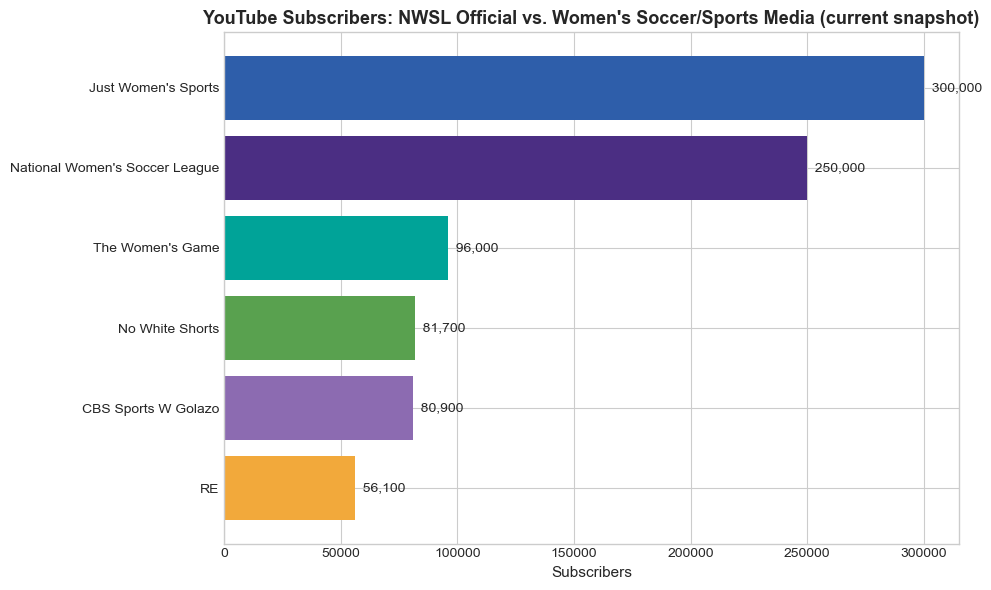

In [7]:
youtube_channels = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "youtube_channels.csv"))
youtube_videos = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "youtube_videos.csv"))
youtube_videos["published_at"] = pd.to_datetime(youtube_videos["published_at"])

CHANNEL_COLORS = {
    "National Women's Soccer League": "#4B2E83", 
    "The Women's Game": "#00A398",
    "RE": "#F2A93B",
    "Just Women's Sports": "#2E5EAA",
    "CBS Sports W Golazo": "#8C6BB1",
    "No White Shorts": "#59A14F",
}

# Current subscriber snapshot, sorted
snapshot = youtube_channels.sort_values("subscriber_count")
colors = [CHANNEL_COLORS.get(c, "#999999") for c in snapshot["channel_name"]]

plt.figure(figsize=(10, 6))
plt.barh(snapshot["channel_name"], snapshot["subscriber_count"], color=colors)
for i, (name, subs) in enumerate(zip(snapshot["channel_name"], snapshot["subscriber_count"])):
    plt.text(subs, i, f"  {subs:,}", va="center", fontsize=10)
plt.title("YouTube Subscribers: NWSL Official vs. Women's Soccer/Sports Media (current snapshot)")
plt.xlabel("Subscribers")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "youtube_subscriber_snapshot.png"), dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
plt.close()

### NWSL's own channel: upload cadence and cumulative views, by year

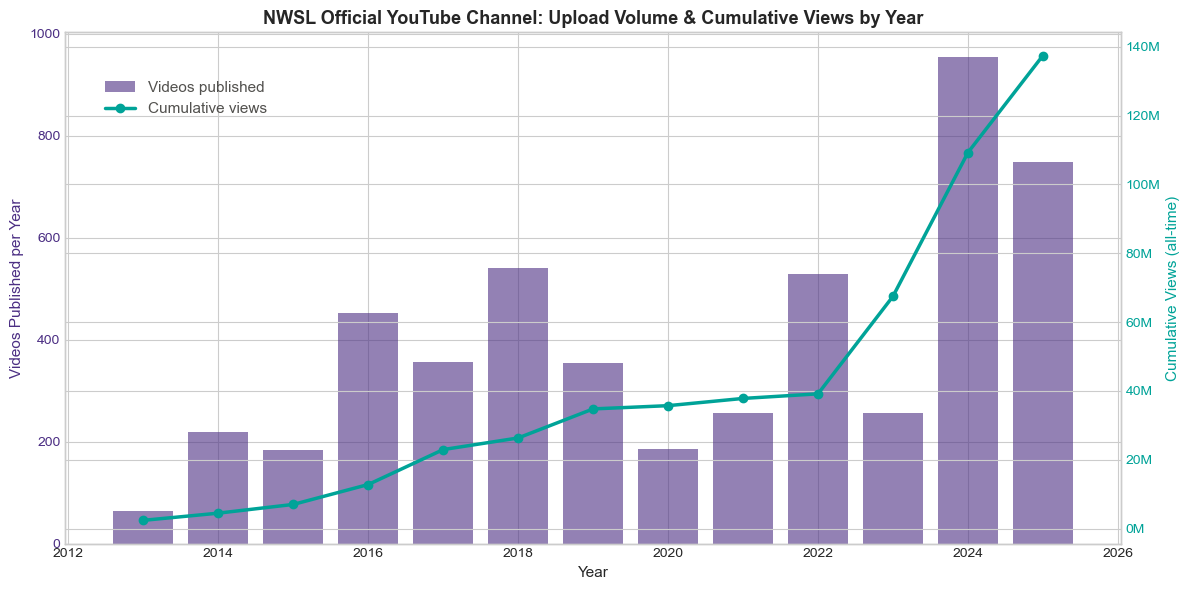

In [8]:
# 2026 is only partway through, so it's excluded
nwsl_videos = youtube_videos[youtube_videos["channel_name"] == "National Women's Soccer League"]
nwsl_yearly = nwsl_videos[nwsl_videos["publish_year"] < 2026].groupby("publish_year").agg(
    videos_published=("video_id", "count"), views=("view_count", "sum")
)
nwsl_yearly["cumulative_views"] = nwsl_yearly["views"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(nwsl_yearly.index, nwsl_yearly["videos_published"], color="#4B2E83", alpha=0.6, label="Videos published")
ax1.set_xlabel("Year")
ax1.set_ylabel("Videos Published per Year", color="#4B2E83")
ax1.tick_params(axis="y", labelcolor="#4B2E83")

ax2 = ax1.twinx()
ax2.plot(nwsl_yearly.index, nwsl_yearly["cumulative_views"], color="#00A398", linewidth=2.5, marker="o",
         label="Cumulative views")
ax2.set_ylabel("Cumulative Views (all-time)", color="#00A398")
ax2.tick_params(axis="y", labelcolor="#00A398")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x / 1e6:.0f}M")

ax1.set_title("NWSL Official YouTube Channel: Upload Volume & Cumulative Views by Year")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88), frameon=False, fontsize=11, labelcolor="#52514e")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "youtube_nwsl_channel_growth.png"), dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
plt.close(fig)

### The rise of women's-soccer/sports-specific media

Every channel here except the NWSL's own posts more than just NWSL content, but their existence and growth at all is itself evidence of a broader shift, which is what this chart is after: total video uploads per year across all 6 channels, stacked by channel.

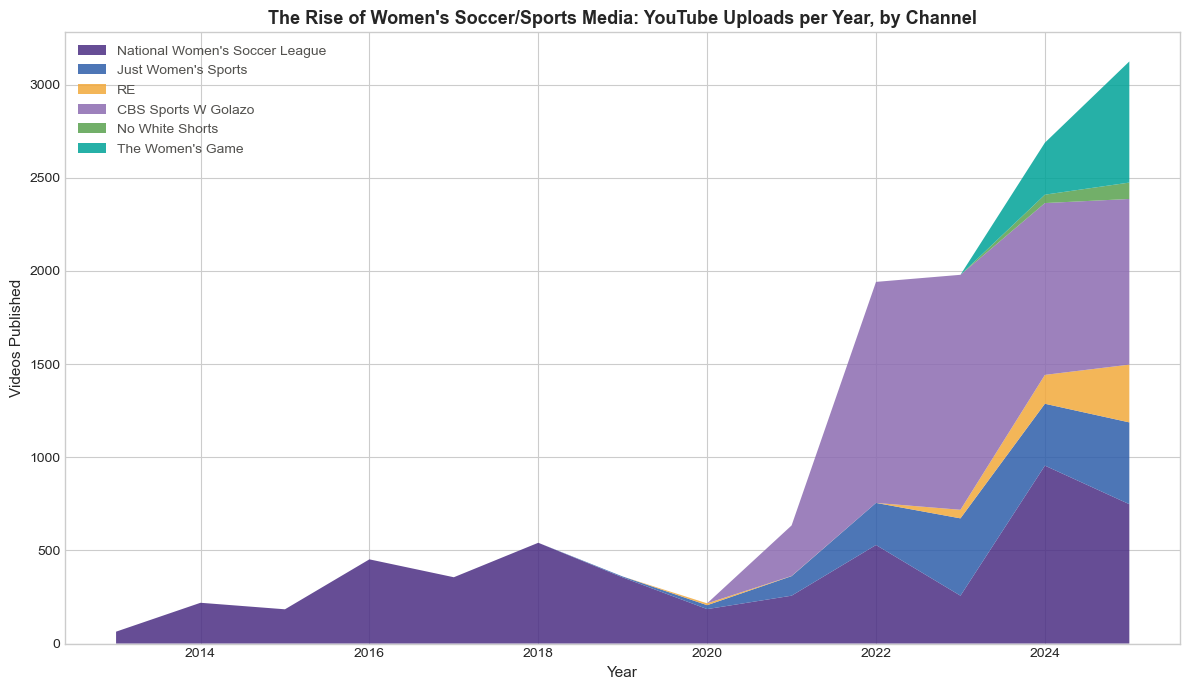

In [9]:
yearly_by_channel = (
    youtube_videos[(youtube_videos["publish_year"] >= 2013) & (youtube_videos["publish_year"] < 2026)]
    .groupby(["publish_year", "channel_name"])
    .size()
    .unstack(fill_value=0)
)
# Stack order: NWSL on the bottom (it's the constant), independents on top in the order
# they launched, so the widening stack visually reads as new entrants arriving over time
stack_order = ["National Women's Soccer League", "Just Women's Sports", "RE", "CBS Sports W Golazo",
               "No White Shorts", "The Women's Game"]
yearly_by_channel = yearly_by_channel[[c for c in stack_order if c in yearly_by_channel.columns]]

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(
    yearly_by_channel.index,
    [yearly_by_channel[c] for c in yearly_by_channel.columns],
    labels=yearly_by_channel.columns,
    colors=[CHANNEL_COLORS.get(c, "#999999") for c in yearly_by_channel.columns],
    alpha=0.85,
)
ax.set_title("The Rise of Women's Soccer/Sports Media: YouTube Uploads per Year, by Channel")
ax.set_xlabel("Year")
ax.set_ylabel("Videos Published")
ax.legend(loc="upper left", frameon=False, fontsize=10, labelcolor="#52514e")
ax.set_facecolor("white")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "youtube_womens_media_rise.png"), dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
plt.close(fig)

## Positive vs. negative coverage, over time

VADER sentiment split from `05` (`nwsl_articles_with_sentiment.csv`) -- positive/negative/neutral share of NWSL-related headlines, by year. Titles are short, so treat this as a coarse signal (a headline rarely carries much sentiment-bearing language), but the direction of the split over time is still informative.

In [10]:
import plotly.express as px
from plot_theme import style_plotly_fig

sentiment_media = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_articles_with_sentiment.csv"))
sentiment_media["publish_date"] = pd.to_datetime(sentiment_media["publish_date"])
sentiment_media["year"] = sentiment_media["publish_date"].dt.year

sentiment_by_year = (
    sentiment_media.groupby(["year", "sentiment_label"]).size()
    .rename("article_count").reset_index()
)
sentiment_by_year["share"] = (
    sentiment_by_year["article_count"] / sentiment_by_year.groupby("year")["article_count"].transform("sum")
)

fig = px.bar(
    sentiment_by_year, x="year", y="share", color="sentiment_label",
    color_discrete_map={"positive": "#00A398", "neutral": "#8C6BB1", "negative": "#E34948"},
    category_orders={"sentiment_label": ["positive", "neutral", "negative"]},
    labels={"share": "Share of Articles", "year": "Year", "sentiment_label": "VADER sentiment"},
    title="<b>NWSL Media Coverage: Positive vs. Negative Share, by Year</b>",
)
fig = style_plotly_fig(fig)
fig.update_layout(barmode="stack", height=460, margin={"t": 60, "b": 40, "l": 10, "r": 10})
fig.update_yaxes(tickformat=".0%")
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_sentiment_share_by_year.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91538/714173805.py:26: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_sentiment_share_by_year.png"))
